In [17]:
from functions.internal import load_dataset_1B, normalization
from functions.SQUIC_functions import squic_fit_matrix_computation, squic_fit_computation, check_symmetric_sparse
from functions.clustering_functions import clustering_optimal_number, modularity_density, study_CC
from functions.plots import plot_timeseries, plot_knn, plot_PDens_Q
from functions.cosmograph_functions import visualize_graph, visualize_graph_internal
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science'])
import json
from scipy import sparse
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import numpy as np
import os

In [18]:
def ask_yes_no(prompt, default=None):
    """
    Ask the user a yes/no question with optional default.
    """
    while True:
        answer = input(f"{prompt} (Y/N) ").strip().upper()
        if not answer and default:
            return default
        if answer in ['Y', 'N']:
            return answer
        print("Please enter 'Y' or 'N'.")


def ask_input(prompt, default=None):
    """
    Ask the user for input with optional default.
    """
    answer = input(f"{prompt} ").strip()
    if not answer and default is not None:
        return default
    return answer

Head of Y_norm df:
              0         1         2         3         4         5         6  \
0  1.814374e-01  0.181437  0.181437  0.181437  0.181437  0.181437  0.181437   
1  1.917980e-04  0.000192  0.000192  0.000192  0.000192  0.000192  0.000192   
2  2.112568e-01  0.211257  0.211257  0.211257  0.211257  0.211257  0.211257   
3  1.324886e-08 -0.000167 -0.000334 -0.000334 -0.000334 -0.000334 -0.000334   
4  1.713108e-01  0.171311  0.171311  0.171311  0.171311  0.171311  0.171311   

          7         8         9  ...       190       191       192       193  \
0  0.198751  0.198751  0.198751  ... -2.919603 -2.919603 -2.919603 -2.919603   
1  0.000192  0.000000  0.000000  ...  0.263401  0.263401  0.263401  5.512724   
2  0.000015  0.000015 -0.211227  ... -3.802339 -3.802339 -3.802339 -3.802339   
3 -0.000334 -0.000334 -0.000334  ...  3.982279  3.982279  3.982113  3.982113   
4  0.000011  0.000011  0.000011  ... -3.083379 -3.083379 -3.083379 -3.083379   

        194       195    

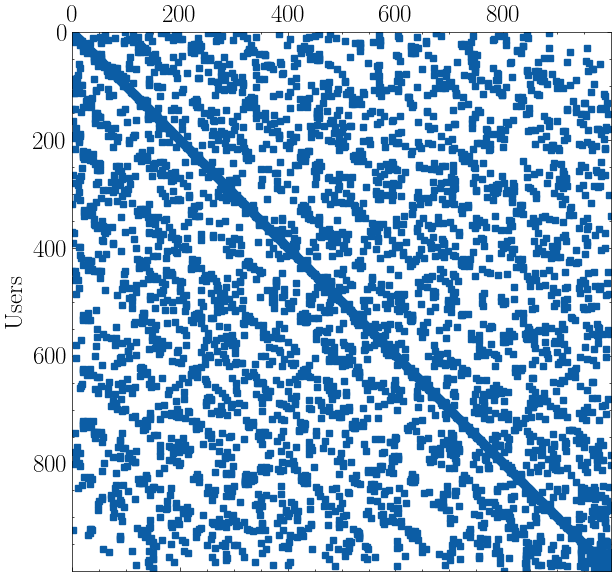


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    6.820000e+00
 Y:         1000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.900000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=1.75e+01 time=5.02e-03
* iter=1 time=7.36e-03 obj=1.80e+03 |delta(obj)|/obj=4.44e-01 nnz(X,L,W)/p=[1.75e+01 1.95e+01 1.01e+00] lns_iter=4 
* iter=2 time=9.99e-03 obj=1.69e+03 |delta(obj)|/obj=6.28e-02 nnz(X,L,W)/p=[1.75e+01 1.95e+01 4.44e+01] lns_iter=4 
* iter=3 time=8.92e-02 obj=1.61e+03 |d

In [19]:
user_input = ask_yes_no("\nDo you want to load data?")

if user_input == 'Y':
    dimension = ask_input("Which dimension (100/1K/10K/100K/1M)?").upper()
    path = 'amlsim_data_saved'

    try:
        # Load pre-saved Y_norm
        chunk_size = 10000
        chunks = []

        for chunk in pd.read_csv(f'{path}/YNorm_{dimension}.csv', chunksize=chunk_size):
            chunks.append(chunk)

        Y_norm = pd.concat(chunks, ignore_index=True)
        print(f"Head of Y_norm df:")
        print(Y_norm.head())

        print(f"\ndimension of YNorm loaded: {Y_norm.shape}")

        std_dev = round(np.mean(np.std(Y_norm, axis=1)), 2)

        if not(std_dev > 0.9 and std_dev <= 1):
            print("Mean std per row (should be 1):", std_dev)
            print("Max:", np.max(Y_norm))
            print("Min:", np.min(Y_norm))

            # Step 1: Convert DataFrame to NumPy array for performance
            Y = Y_norm.to_numpy()  # shape: (num_users, num_days)

            # Step 2: Compute row-wise standard deviation
            stds = np.std(Y, axis=1)
            safe_stds = np.clip(stds, 1e-8, None)  # Avoid division by near-zero

            # Step 3: Normalize each row by its std using broadcasting
            Y = Y / safe_stds[:, np.newaxis]

            Y_norm = pd.DataFrame(Y, index=Y_norm.index, columns=Y_norm.columns)

            print(f"Head of Y_norm df:")
            print(Y_norm.head())

            print("Mean std after normalization (should be ~1):", np.mean(np.std(Y_norm, axis=1)))
            print("Max:", np.max(Y_norm))
            print("Min:", np.min(Y_norm))
        else:
            print("Mean std per row (should be 1):", std_dev)

        # Load pre-saved knn_matrix
        knn_matrix = sparse.load_npz(f'{path}/knn_matrix_{dimension}.npz')

        print("Shape KNN:", knn_matrix.shape)
        print("nnz KNN:", knn_matrix.nnz)

        # Average number of non-zeros per row
        nnz_per_row = knn_matrix.nnz / knn_matrix.shape[0]
        print("nnz per row:", round(nnz_per_row, 2))

        print("Is symmetric:", check_symmetric_sparse(knn_matrix))
        
        # Load pre-saved account_properties
        with open(f'{path}/account_prop_{dimension}.json', 'r') as f:
            account_prop = json.load(f)

        account_prop = {int(k): v for k, v in account_prop.items()}
        
        name = 'PAYSIM'

    except Exception as e:
        # If data are not present
        print(f"Error loading data: {e}")
        exit(1)
    
else: # Normal run
    Y, name, dimension, account_prop = load_dataset_1B()

    # visualize timeseries
    plot_timeseries(Y, name, dimension)

    print(Y)

    # now this is good
    print(Y.shape)
    dim1, dim2 = Y.shape
    if dim1 == 365:
        Y = Y.T

    # norm is ok -> lead to SQUIC-Fit results that we want
    Y_norm = normalization(Y, name)

    # visualize timeseries with normalized data
    plot_timeseries(Y_norm, name, dimension, type_df='norm')

    print(Y_norm)

    print("NaNs in df?", np.isnan(Y_norm.values).any())
    print("Infs in df?", np.isinf(Y_norm.values).any())
    print("Max:", np.max(Y_norm))
    print("Min:", np.min(Y_norm))
    print("Mean std per row (should be 1):", round(np.mean(np.std(Y_norm, axis=1)), 2))

    n_neigs = {
        '100' : 10,
        '1K' : 8,
        '10K' : 4,
        '100K' : 3,
        '1M' : 2 # then remove self loops
    }

    nbrs = NearestNeighbors(n_neighbors=n_neigs[dimension], metric='euclidean', n_jobs=-1)
    nbrs.fit(Y_norm)
    knn_matrix = nbrs.kneighbors_graph(Y_norm, mode='connectivity')

    if dimension == '1M':
        # Remove self-loops
        knn_matrix.setdiag(0)
        knn_matrix.eliminate_zeros()
    
    # Ask user if want to save the data for next runs
    if ask_yes_no("Do you want to cache this data?") == 'Y':
        path = 'paysim_data_saved'

        # if path does not exists, create it
        os.makedirs(path, exist_ok=True)
        
        # Save Y_norm as CSV
        pd.DataFrame(Y_norm).to_csv(f'{path}/YNorm_{dimension}.csv', index=False)
        
        # Save account_prop as json
        with open(f'{path}/account_prop_{dimension}.json', 'w') as f:
            json.dump(account_prop, f)
        
        # Save knn_matrix as npz
        sparse.save_npz(f'{path}/knn_matrix_{dimension}.npz', knn_matrix)

results_squic = {}

# Run SQUIC_fit
if ask_yes_no("SQUIC-Fit with bias or no?") == 'Y':

    os.makedirs(f'images/{dimension}/', exist_ok=True)

    plot_knn(knn_matrix, dimension)

    if ask_yes_no("Do you want to study the CC of KNN matrix?") == 'Y':
        study = True
        study_CC(knn_matrix)

    if ask_yes_no("Do you want to visualize the results of SQUIC-Fit?") == 'Y':
        printMatrix = True
    else:
        printMatrix = False

    if ask_yes_no("Do you want to save the results of SQUIC-Fit?") == 'Y':
        save = True
    else:
        save = False
    
    squic_method = 'squic-fit-matrix'
    results_squic[squic_method] = squic_fit_matrix_computation(Y_norm, name, dimension, knn_matrix, printMatrix, save)

else:
    if ask_yes_no("Do you want to visualize the results of SQUIC-Fit?") == 'Y':
        printMatrix = True
    else:
        printMatrix = False

    if ask_yes_no("Do you want to save the results of SQUIC-Fit?") == 'Y':
        save = True
    else:
        save = False

    squic_method = 'squic-fit'
    results_squic[squic_method] = squic_fit_computation(Y_norm, name, dimension, printMatrix, save)

Is G connected for l=0.99? False
# CC : 48
Is G connected for l=0.97? False
# CC : 24
Is G connected for l=0.95? False
# CC : 12
Is G connected for l=0.9? False
# CC : 10
Is G connected for l=0.85? False
# CC : 10
Is G connected for l=0.8? False
# CC : 10
For rho 0.99:
    louvain: PDensity = 0.07, Int Density = 0.39, Q = 0.85, nCluster = 63, nIsolated  = 39
    leiden: PDensity = 0.1, Int Density = 0.39, Q = 0.85, nCluster = 70, nIsolated  = 39
    dbscan: PDensity = 0.01, Int Density = 0.02, Q = 0.45, nCluster = 73, nIsolated  = 69
    spectral: PDensity = 0.01, Int Density = 0.57, Q = 0.01, nCluster = 3, nIsolated  = 0
For rho 0.97:
    louvain: PDensity = 0.1, Int Density = 0.44, Q = 0.84, nCluster = 40, nIsolated  = 19
    leiden: PDensity = 0.17, Int Density = 0.38, Q = 0.81, nCluster = 35, nIsolated  = 21
    dbscan: PDensity = 0.15, Int Density = 0.03, Q = 0.52, nCluster = 51, nIsolated  = 47
    spectral: PDensity = 0.02, Int Density = 0.05, Q = 0.01, nCluster = 2, nIsolated  

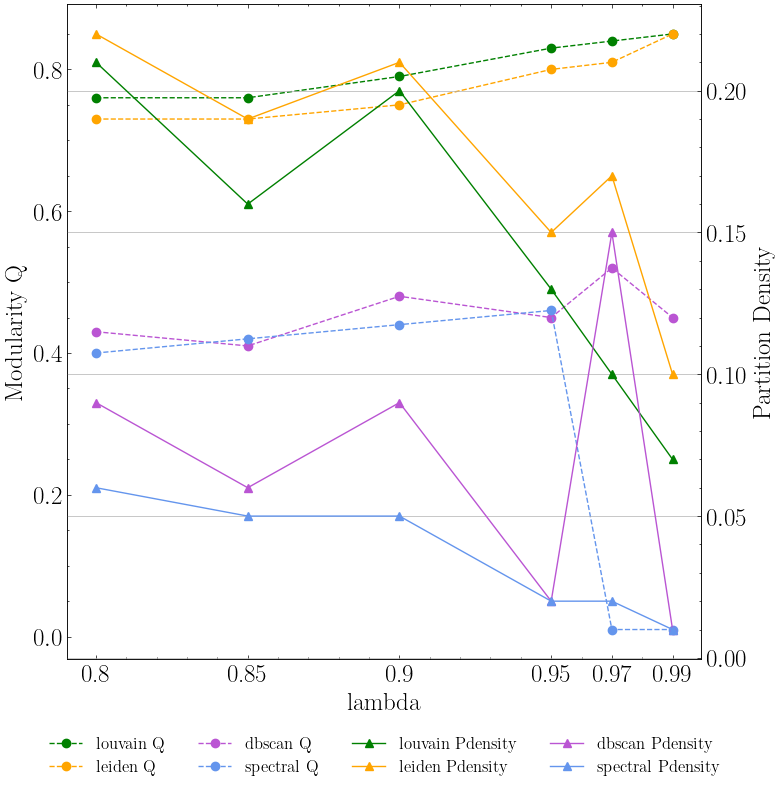

In [20]:
# Results
dict_cluster = clustering_optimal_number(dimension, results_squic, plot=False)

metrics = modularity_density(dict_cluster, results_squic, leiden=True)

for rho, data in metrics.items():
    print(f"For rho {rho}:")
    for method, results in data.items():
        print(f"    {method}: PDensity = {results['p_density']}, Int Density = {results['int_density']}, Q = {results['modularity']}, nCluster = {results['nCluster']}, nIsolated  = {results['isolated']}")

plot_PDens_Q(name, metrics, dimension, squic_method, save)

In [21]:
import networkx as nx
from cosmograph import cosmo

COLOR_LIST = [
    ["0", "#4682B4"],  # Steelblue
    ["1", "#FF9999"],  # Red/Pink
    ["2", "#4169E1"],  # Royal Blue
    ["3", "#FFD700"],  # Yellow
    ["4", "#FFCC99"],  # Orange
    ["5", "#CCFFE5"],  # Light blue
    ["6", "#FFFF99"],  # Yellow
    ["7", "#CCFF99"],  # Lime
    ["8", "#CCFFFF"],  # Cyan
    ["9", "#CCCCFF"],  # Lilla
    ["10", "#E9967A"],  # Dark Salmon
    ["11", "#E5CCFF"],  # Dark Lilla
    ["12", "#DC143C"], # Crimson Red
    ["13", "#FFFFFF"], # White
    ["14", "#F0FFF0"],  # Honeydew,
]

def visualize_graph_external(W_matrices, squic_method, dict_partition, account_prop, name, color_by='community'):

    widget_dict = {
        rho: {
            'louvain' : {},
            'dbscan' : {},
            'spectral' : {}
        } for rho in W_matrices[squic_method].keys()
    }
    
    for clustering_method, dictionary_clusters in dict_partition.items():
        for rho, partition in dictionary_clusters.items():
            for rho, X in W_matrices[squic_method].items():
                # Create a graph from matrix X
                G = nx.from_numpy_array(X)

                # Extract clustering associated to matrix X with l=rho and method 
                # partition = clustering[rho]
                
                # Convert partition list of sets to a node-to-community mapping
                community_mapping = {}
                for community_id, community_set in enumerate(partition):
                    for node in community_set:
                        community_mapping[node] = str(community_id)

                # Sets node attributes from a given value or dictionary of values.
                nx.set_node_attributes(G, community_mapping, 'community')

                fraud_mapping = {}
                for node in G.nodes():
                    if node in account_prop and isinstance(account_prop[node], dict):
                        if 'fraud' in account_prop[node]:
                            fraud_mapping[node] = account_prop[node]['fraud']
                    else:
                        # Default value if node not found in account_prop
                        fraud_mapping[node] = False
                
                # Set fraud attributes for all nodes
                nx.set_node_attributes(G, fraud_mapping, 'fraud')

                # Nodes: build dataframe from node attributes
                nodes_data = []
                fraudolent = []

                for node, data in G.nodes(data=True):
                    is_fraud = data.get('fraud', False)

                    # Create conditional label - only show label ID if fraudulent
                    label = str(node) if is_fraud else ""

                    if is_fraud:
                        fraudolent.append(str(node))

                    nodes_data.append({
                        'id': node,
                        # 'label': str(node),
                        'label' : label,
                        'community': data.get('community'),
                        'color': data.get('color'),
                        'degree': G.degree[node],
                        'fraud' : is_fraud,
                    })
                
                points = pd.DataFrame(nodes_data)

                points['community'] = points['community'].astype('category')

                # Edges: extract links with weights
                links_data = []
                for u, v, d in G.edges(data=True):
                    links_data.append({
                        'source': u,
                        'target': v,
                        'weight': d.get('weight', 1.0)
                    })
                links = pd.DataFrame(links_data)
                links['weight'] = links['weight'].abs()  # only positive thickness
                # links['weight'] = links['weight'] * 10  # only positive thickness
                
                # COSMOGRAPH docs: https://colab.research.google.com/drive/1Rt8rmmeMuWyFjEqae2DdJ3NYymtjC9cT#scrollTo=IZUK7ioL1xKr
                widget = cosmo(
                    points=points,
                    links=links,
                    point_id_by='id',
                    link_source_by='source',
                    link_target_by='target',
                    link_width_by='weight', # width of an edge given by weight = value in X between i and j
                    link_color='#E3E3E3',
                    link_greyout_opacity=0.1,
                    # link_color_by='community',
                    point_color_by=color_by,
                    point_label_by='id', # [id, class, fraud]
                    point_size_by='degree',
                    point_color_strategy='map',
                    point_color_by_map=COLOR_LIST,
                    background_color='#FFFFFF',
                    show_labels_for=fraudolent
                )

                widget_dict[rho][clustering_method] = widget
    
    return widget_dict


In [22]:
normal_graph = visualize_graph_external(results_squic, squic_method, dict_cluster, account_prop, name)

In [25]:
rho = 0.99

In [27]:
normal_graph[rho]['spectral']

Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_colo…